In [88]:
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from operator import add
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.documents import Document

In [89]:
llm =ChatOllama(model="llama3.2:1b")
embedding_model=OllamaEmbeddings(model="nomic-embed-text:latest")

In [102]:
class GraphState(TypedDict):

    question: str
    pdf: List[Document]
    documents: List[Document]
    answer: str
    count: int

In [ ]:
loader = PyPDFLoader("Mouzan_Raza_Resume.pdf")  # your PDF path
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
chunks = splitter.split_documents(docs)

vectordb = FAISS.from_documents(chunks, embedding_model)

retriever = vectordb.as_retriever()

In [92]:
def retrieve(state: GraphState) -> GraphState:
    docs = retriever.invoke(state["question"])

    return {
        "pdf": docs
    }

In [93]:
def grade_documents(state: GraphState) -> GraphState:
    chunks = state["pdf"]
    query = state["question"]
    count=state["count"]
    prompt=f"""
    Analysis the following text {chunks} and question {query} if the answer of the question is in text you answere should only yess other wise no
    
    """
    if count>2:
        return "generate_ans"
    answer=llm.invoke(prompt).content
    if "yes" in answer.lower():
        return "generate_ans"
    else:
        return "rewrite_query"
    

In [94]:
def rewrite_query(state):

    question = state["question"]
    prompt=f"Analysis the user question {question} and rewrite it in a more clear way so retriver can understand it"

    return {
        "question": llm.invoke(prompt).content
    }

    

In [95]:
def increment_count(state):
    return {
        "count": state["count"] + 1
    }

In [96]:
def generate(state):

    context = "\n\n".join(
        [doc.page_content for doc in state["pdf"]]
    )

    answer = f"""
    Generate Answere from this given context and question
Question:

{state['question']}

Context:

{context}
 if do not know the answer please say 'I don't know'
"""

    return {
        "answer": llm.invoke(answer).content
    }

In [97]:
graph=StateGraph(GraphState)

In [98]:
graph.add_node("retrieve",retrieve)
graph.add_node("rewrite_query",rewrite_query)
graph.add_node("increment_count",increment_count)
graph.add_node("generate",generate)

In [99]:
graph.add_edge(START,"retrieve")
graph.add_conditional_edges("retrieve",grade_documents,{"generate_ans":"generate","rewrite_query":"rewrite_query"})
graph.add_edge("rewrite_query","increment_count")
graph.add_edge("increment_count","retrieve")
graph.add_edge("generate",END)

In [100]:
app=graph.compile()

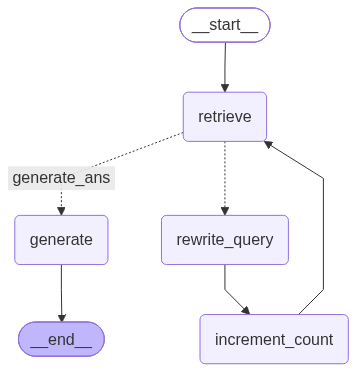

In [101]:
app

In [103]:
result = app.invoke(
    {
        
        "question":"What is the main skill of person",
        
        "count":0
    }
)

print(result["answer"])

Based on the context and question, here's a possible answer:

The most essential skills required for someone to succeed in AI/Machine Learning development are:

* Strong programming skills in Python, particularly Scikit-learn, TensorFlow, XGBoost, and HuggingFace
* Proficiency in NLP tools like Google Gemini, Streamlit, and LangGraph
* Experience with generative AI technologies like RAG and CrewAI
* Knowledge of cloud platforms such as AWS or GCP for deploying models
* Understanding of data engineering concepts and fine-tuning techniques (e.g., LOAR)
* Familiarity with APIs and RESTful programming
* Creativity and passion for building practical, production-ready AI solutions

Note that this answer is based on the skills and expertise mentioned in the context provided.


In [104]:
result

{'question': 'Here\'s a rewritten version of your original question in a clearer and more concise manner:\n\n"What are the most essential skills required for someone to succeed in [industry/field]?"\n\nThis revised question still conveys the idea that you\'re looking for a general answer, but it\'s more focused on what\'s valuable or characteristic of success in the industry.',
 'pdf': [Document(id='d16ed2ea-49b9-48da-a95e-54ef22331a4c', metadata={'producer': 'Microsoft® Word 2016', 'creator': 'Microsoft® Word 2016', 'creationdate': '2026-03-30T16:46:05+05:00', 'author': 'Un-named', 'moddate': '2026-03-30T16:46:05+05:00', 'source': 'Mouzan_Raza_Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Developer. Skilled in building ML pipelines, NLP systems, RAG applications, and REST APIs. Passionate about \nGenerative AI and building practical, production-ready AI solutions.'),
  Document(id='617fe114-0746-4b84-9a19-115416d78039', metadata={'producer': 'Microsoft® W